# 8-7. 손님의 성별,수, 전체 먹은 금액 등으로 내가 받은 팁을 예측할 수 있을까?

In [ ]:
# 자, 우리는 이전 단계에서 단 하나의 정보인 "사용 연수"만을 
# 가지고 맥북의 중고가를 예측해 보는 일차함수 모델을 설계하고 학습도 시켜보았습니다.

# 손님의 성별, 수, 전체 먹은 금액 등으로 내가 받을 팁을 예측할 수 있을까?

# 다변수 데이터에 대해 선형회귀를 하기 위한 데이터를 확인하고 모델 설계하기


#자, 이번에 사용할 데이터에는 단 하나의 정보만이 담겨있지 않습니다. 여러 가지 변수로 하나의 값이 결정되죠.

#우리는 이번에 손님 테이블에 대한 여러 가지 정보가 담긴 데이터셋으로 그 테이블이 낼 팁(tip)을 예측해 볼 것입니다.
#어떤 정보가 있고, 그 정보를 활용해서 효과적으로 팁을 예측할 수 있을지 실험해 보죠.

#팁 데이터셋은 데이터 시각화 패키지인 seaborn 패키지 안에 포함되어 있습니다.

In [4]:
import seaborn as sns

print(sns.get_dataset_names())

# 비행 데이터를 담은 flights, 붓꽃 데이터를 담은 iris 등 여러 가지 데이터가 있네요.
# 이 중 우리가 오늘 사용해 볼 팁 데이터는 sns.load_dataset("tips") 으로 가져올 수 있습니다.
    
tips = sns.load_dataset("tips")
print(tips.shape)
tips.head()

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']
(244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
# 총 244개의 행과 7개의 열로 이루어져 있군요.
# 각 데이터는 total_bill, tip, sex, smoker, day, time, size 7개의 정보를 담고 있습니다.

# 각 컬럼은 다음과 같은 정보를 나타내죠.
# total_bill : 테이블의 전체 지불 금액
# tip : 팁으로 낸 금액
# sex : 계산한 손님의 성별
# smoker : 손님 중 흡연자 포함 여부
# day : 요일
# time : 시간
# size : 테이블 인원수

# 따라서 다음과 같이 판다스의 get_dummies() 함수를 활용해 문자열 데이터에 대해서는 0, 1 로 변환해주겠습니다.
# 수식을 구할 때 카테고리형 데이터가 있다면 더미 변수(dummy variable)를 활용해 식에 포함시켜 줄 수 있습니다.

import pandas as pd
tips = pd.get_dummies(tips, columns=['sex', 'smoker', 'day', 'time'])
tips.head()


,total_bill,tip,size,sex_Male,sex_Female,smoker_Yes,smoker_No,day_Thur,day_Fri,day_Sat,day_Sun,time_Lunch,time_Dinner
0,16.99,1.01,2,False,True,False,True,False,False,False,True,False,True
1,10.34,1.66,3,True,False,False,True,False,False,False,True,False,True
2,21.01,3.50,3,True,False,False,True,False,False,False,True,False,True
3,23.68,3.31,2,True,False,False,True,False,False,False,True,False,True
4,24.59,3.61,4,False,True,False,True,False,False,False,True,False,True


In [6]:
# 이러한 데이터 변환 방식을 원-핫 인코딩(One Hot Encoding) 이라고 하죠. 이미 알고 계실 것이라 생각합니다!

# 그렇다면 꼭 해야 하는 것은 아니지만, 컬럼의 순서를 우리의 목적에 맞게 바꾸어보겠습니다.

# 우리는 나머지 모든 데이터를 가지고 최종적으로 tip 값을 예측하려고 합니다. 따라서 tip 컬럼을 맨 오른쪽에 두도록 하겠습니다.
tips = tips[['total_bill', 'size', 'sex_Male', 'sex_Female', 'smoker_Yes', 'smoker_No',
             'day_Thur', 'day_Fri', 'day_Sat', 'day_Sun', 'time_Lunch', 'time_Dinner', 'tip']]
tips.head()

,total_bill,size,sex_Male,sex_Female,smoker_Yes,smoker_No,day_Thur,day_Fri,day_Sat,day_Sun,time_Lunch,time_Dinner,tip
0,16.99,2,False,True,False,True,False,False,False,True,False,True,1.01
1,10.34,3,True,False,False,True,False,False,False,True,False,True,1.66
2,21.01,3,True,False,False,True,False,False,False,True,False,True,3.50
3,23.68,2,True,False,False,True,False,False,False,True,False,True,3.31
4,24.59,4,False,True,False,True,False,False,False,True,False,True,3.61


이전에 입력 데이터가 "사용연수"로 단 한 개였을 때 우리는 모델을 다음과 같이 설정하였습니다.

y=wx+b

그렇다면 이번에는 x가 한 개가 아닌, 12개나 됩니다! 그렇기에 우리는 모델을 다음과 같이 설정해 볼 수 있죠.

# 선형 회귀

In [ ]:
# 이러한 식을 우리는 선형 방정식이라고 합니다. 다른 말로는 "다변수 일차방정식"이라고 할 수도 있죠.

# 중요한 것은, 우리는 각각의 x에 개별 가중치를 곱해주는 것 말고는 다른 조작을 하지 않는다는 것입니다.

# 이렇게 선형 방정식을 활용해서 원하는 값을 예측하는 모델을 설계하고 학습시키는 방법을 선형 회귀 라고 합니다.

# 사진을 입력받아 해당 사진이 강아지인지, 고양이인지 맞히는 문제는 분류 문제입니다.
# 사용연수, 화면크기 등을 입력받아 실수값인 중고 가격을 맞히는 문제는 회귀 문제입니다.
# 즉, 분류 문제는 맞히고자 하는 값이 카테고리 이고, 회귀 문제는 맞히고자 하는 값이 연속된 실수 값 입니다.



# 시각화

In [ ]:
# 다만, 여기에서 안타까운 점이 하나 있습니다.
# 우리는 위에서 x축과 y축을 활용해서 2차원 평면에 데이터를 찍어서 시각화할 수 있었습니다.

# 만약 입력 데이터인 x가  x1, x2 로 두 개이고, 그 두 값으로 

# y값이 정해진다면 다음과 같은 3차원 공간에 시각화를 해 볼 수 있겠죠.


# 8-8. 다시 한 번 직접 설계해 보는 손실함수

In [8]:
# 다변수 데이터에 대해 선형회귀를 하기 위한 손실함수를 정의하기 
# 그러면 이제 본격적으로 데이터를 준비하고 모델을 설계해서 학습을 시켜 보겠습니다!

# 먼저 데이터는 다음과 같이 준비하면 됩니다. 다만, 앞으로는 X는 하나의 값이 아닌
# 12개의 값을 가지는 벡터 이므로, 대문자로 표기하도록 하겠습니다.
X = tips[['total_bill', 'size', 'sex_Male', 'sex_Female', 'smoker_Yes', 'smoker_No',
          'day_Thur', 'day_Fri', 'day_Sat', 'day_Sun', 'time_Lunch', 'time_Dinner']].values
y = tips['tip'].values
print("슝=3")

슝=3


In [9]:
# 자아, 준비가 되어가고 있습니다.

# 한 가지 잊지 말아야 할 단계는, 데이터를 train 데이터와 test 데이터로 분리하는 것입니다

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(195, 12) (195,)
(49, 12) (49,)


In [10]:

# 입력 데이터와 정답 데이터는 준비가 완료되었네요!

# 다음으로, W와 b는 랜덤한 값으로 초기값을 설정해주도록 하겠습니다. W 또한 벡터이므로 대문자를 사용합니다.

In [11]:
#길이가 12인 W와 1개의 숫자인 b를 준비합니다.

import numpy as np
W = np.random.rand(12)
b = np.random.rand()
print("슝=3")

슝=3


In [14]:
W

array([0.82066048, 0.52562004, 0.85146544, 0.34604997, 0.01586757,
       0.09764198, 0.52774214, 0.45886451, 0.22489073, 0.38410329,
       0.76888379, 0.47707957])

In [15]:
b

0.6177002607989228

In [22]:
# 따라서 for 구문을 활용해 1부터 X의 길이 까지 x * w를 수행하고, 마지막에 b를 더해주도록 하겠습니다.
def model(X, W, b):
    predictions = 0
    for i in range(12):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions
print("슝=3")

슝=3


In [23]:
# 간단하네요!

# 손실함수는 이번에는 RMSE 대신 MSE를 사용해 보겠습니다.
# 이전에 사용했던 RMSE는 단지 MSE의 제곱근이었으므로, 이번에는 제곱근하는 과정만 빼면 됩니다.
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse
print("슝=3")

슝=3


In [24]:
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L
print("슝=3")

슝=3


# 8-9 앞으로는 절대 해 볼 일 없을, 직접 그래디언트 계산하기

In [ ]:
# 기울기를 구하는 것은 이전보다는 조금 복잡합니다. 하지만 천천히 보면 어렵지 않습니다.

# 먼저 이전에 우리는 기울기를 미분계수의 정의 식으로 구했습니다. 이번에는 조금 다른 트릭을 사용할 건데, 바로 수학적인 미분 공식을 활용할 것입니다!

In [20]:
# 네, MSE 값은 정답 y와 예측한 y 간의 차이를 제곱해서 평균한 값이었습니다.
# 모델이 잘 예측할수록 MSE 값은 작아지고, 예측을 잘 못할수록 커지는 값이죠.

# 미분식을 코드로 작성하면

In [25]:
def gradient(X, W, b, y):
    # N은 데이터 포인트의 개수
    N = len(y)

    # y_pred 준비
    y_pred = model(X, W, b)

    # 공식에 맞게 gradient 계산
    dW = 1/N * 2 * X.T.dot(y_pred - y)

    # b의 gradient 계산
    db = 2 * (y_pred - y).mean()
    return np.array(dW, dtype=np.float64), db
print("슝=3")

슝=3


In [26]:
# 한번 실험삼아 경사(gradient)를 계산해 볼까요?
dW, db = gradient(X, W, b, y)
print("dW:", dW)
print("db:", db)

dW: [785.86280595  94.6795501   22.83881446  10.9080265   13.33762193
  20.40921903   7.92997187   2.29771472  12.2456632   11.27349117
   8.4708948   25.27594617]
db: 33.74684096269408


In [ ]:
# 기울기까지 준비되었으니 이제 다음 단계로 가보시죠!

# 8-10. 두 준비 되었다면, 모델 학습은 간단하다구!

In [29]:
# 이제 모든 준비가 끝났으니 뭐만 하면 될까요?!
# 반복해서 가중치를 업데이트 하며 학습을 진행해 보시죠!

# 이번에는 학습률을 0.0001로 두겠습니다.

LEARNING_RATE = 0.0001


In [27]:
# 학습 과정은 위에서와 완전히 똑같습니다. gradient를 구하고,
# W와 b를 업데이트하고, 손실함수를 기록합니다.


In [30]:
%%time
losses = []

for i in range(1, 1001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 10 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 10 : Loss 43.5666
Iteration 20 : Loss 6.9693
Iteration 30 : Loss 2.4077
Iteration 40 : Loss 1.8375
Iteration 50 : Loss 1.7645
Iteration 60 : Loss 1.7535
Iteration 70 : Loss 1.7503
Iteration 80 : Loss 1.7480
Iteration 90 : Loss 1.7458
Iteration 100 : Loss 1.7437
Iteration 110 : Loss 1.7416
Iteration 120 : Loss 1.7394
Iteration 130 : Loss 1.7373
Iteration 140 : Loss 1.7352
Iteration 150 : Loss 1.7331
Iteration 160 : Loss 1.7310
Iteration 170 : Loss 1.7290
Iteration 180 : Loss 1.7269
Iteration 190 : Loss 1.7248
Iteration 200 : Loss 1.7228
Iteration 210 : Loss 1.7208
Iteration 220 : Loss 1.7187
Iteration 230 : Loss 1.7167
Iteration 240 : Loss 1.7147
Iteration 250 : Loss 1.7127
Iteration 260 : Loss 1.7107
Iteration 270 : Loss 1.7087
Iteration 280 : Loss 1.7067
Iteration 290 : Loss 1.7047
Iteration 300 : Loss 1.7027
Iteration 310 : Loss 1.7008
Iteration 320 : Loss 1.6988
Iteration 330 : Loss 1.6969
Iteration 340 : Loss 1.6949
Iteration 350 : Loss 1.6930
Iteration 360 : Loss 1.6911


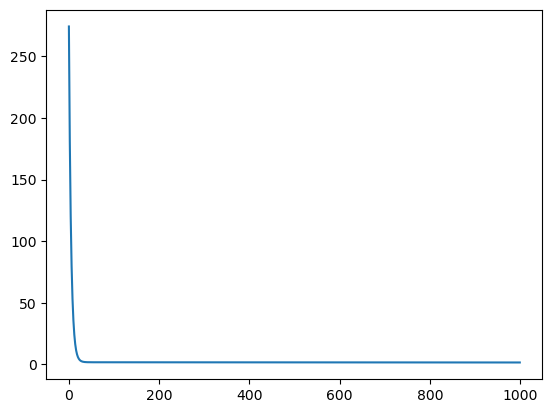

In [31]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.show()

In [32]:
# 아주 효과적으로 잘 내려가는군요. W와 b의 값을 확인해 볼까요?
W, b

(array([ 0.02121805,  0.34135732,  0.78449328,  0.32448028, -0.01440179,
         0.03936948,  0.48475078,  0.44899479,  0.20780308,  0.36551015,
         0.71915038,  0.43827112]),
 np.float64(0.5291584042344841))

In [33]:
# 그렇다면 X_test 데이터와 y_test 데이터에 대해서도 역시 예측을 해 보겠습니다.

# 학습때 보지 않은 test 데이터에 대해서는 loss값이 얼마나 될까요?
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(1.3065062576290039)

In [ ]:
#꽤나 작게 잘 맞히는 것 같습니다.

# 마지막으로 우리의 모델이 예측한 prediction과 실제 정답인 y_test를 비교해서
# 얼마나 잘 맞혔는지 그래프로 확인해 보도록 하겠습니다.

# X_test의 각 행의 첫 번째 데이터가 total_bill이므로, 다음과 같이 시각화를 하면 됩니다.

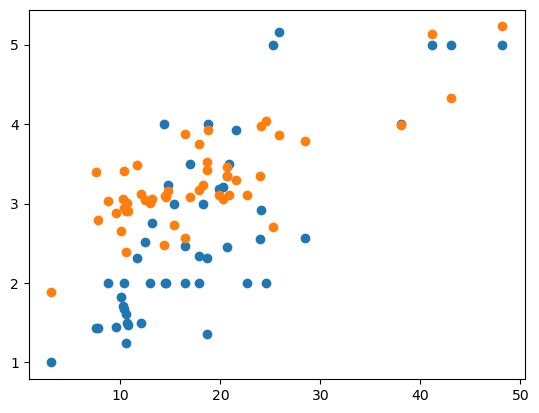

In [34]:
plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()

# 8-11. 지금까지 한 모든 과정을, 라이브러리로 깔끔하게

In [35]:
# 자, 이제 지금까지 학습한 모든 내용을 사이킷런(sklearn) 라이브러리를 활용해서 아주 편리하고 깔끔하게 진행해 보겠습니다.
# 사이킷런을 사용하면 모델이 학습하기 위한 손실함수, 기울기 계산을 직접할 필요가 없기 때문에 매우 간단하게 모델 학습이 완료됩니다.
# 먼저 우리가 사용했던 데이터를 똑같이 준비해 봅시다.

tips = sns.load_dataset("tips")
tips = pd.get_dummies(tips, columns=['sex', 'smoker', 'day', 'time'])
tips = tips[['total_bill', 'size', 'sex_Male', 'sex_Female', 'smoker_Yes', 'smoker_No',
             'day_Thur', 'day_Fri', 'day_Sat', 'day_Sun', 'time_Lunch', 'time_Dinner', 'tip']]
print("슝=3")

슝=3


In [36]:
# 다음으로 위에서 했던 것과 같이 X와 y를 준비하겠습니다.
X = tips[['total_bill', 'size', 'sex_Male', 'sex_Female', 'smoker_Yes', 'smoker_No',
          'day_Thur', 'day_Fri', 'day_Sat', 'day_Sun', 'time_Lunch', 'time_Dinner']].values
y = tips['tip'].values
print("슝=3")

슝=3


In [37]:
# X와 y를 train 데이터와 test 데이터로 분리해 봅시다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("슝=3")

슝=3


In [38]:
# 선형회귀 모델은 sklearn.linear_model 안에 LinearRegression 로 내장되어 있습니다.
from sklearn.linear_model import LinearRegression

model = LinearRegression()
print("슝=3")

슝=3


In [39]:
# 이렇게 하면 모델 준비가 완료됩니다!

# 놀랍지 않나요? 가중치를 따로 선언할 필요도, 손실함수와 기울기를 계산할 필요도 없죠 하하 😅

# 모델 학습은 다음과 같이 입력 데이터에 해당하는 X_train과 정답 데이터에 해당하는 y_train을 넣어 fit 시키면 됩니다.

In [40]:
%%time
model.fit(X_train, y_train)

CPU times: user 5.84 ms, sys: 939 μs, total: 6.78 ms
Wall time: 40.5 ms


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
# 모델 학습이 완료되었네요!

# 이제 X_test 데이터에 대한 예측을 해 볼까요?

In [42]:
predictions = model.predict(X_test)
predictions

array([2.91436632, 2.00292613, 3.96425583, 3.76380832, 2.14836306,
       2.67423448, 3.63934628, 2.29147245, 2.57207155, 2.45851225,
       2.90446763, 2.0573337 , 2.11817193, 2.35130838, 1.82976215,
       3.10830675, 2.95140176, 3.21602976, 2.56640892, 5.73957295,
       3.43490366, 3.22645102, 2.17139823, 1.94180002, 3.16394533,
       2.24547894, 2.14497574, 3.21025435, 3.20097595, 6.66803147,
       5.01111235, 1.57804024, 3.1909877 , 2.76652194, 2.98412862,
       3.85695724, 2.17008741, 5.46673999, 2.35586827, 2.99190732,
       2.03271177, 2.48465991, 3.44046814, 2.35532237, 1.92528104,
       0.87348926, 1.81911521, 3.04083954, 1.85436902])

In [43]:
# 각각의 X 데이터에 대해 tip 데이터를 잘 예측한 것 같습니다.

# 그러면 이제 정답 데이터와 비교해 모델의 성능을 평가해 봅시다.
# 모델의 성능은 mse로 계산해 볼텐데, 이는 sklearn.metrics의 mean_squared_error에 들어있습니다.
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
mse

0.7033566017436103

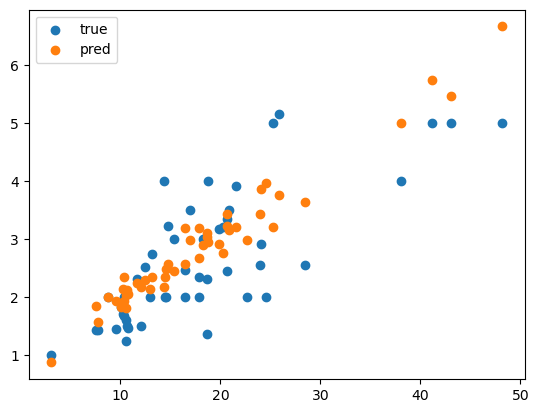

In [44]:
# 0.7 정도의 성능으로, 이전 스텝에서 우리가 직접 만들었던 모델의 0.68과 유사한 성능을 보이는군요.
# 우리가 만들었던 모델도 나쁘지 않았던 것 같습니다.😊

# 위에서 했던 것과 같이 X축에는 total_bill을, y 축에는 tip을 두고 시각화를 해 보겠습니다.
plt.scatter(X_test[:, 0], y_test, label="true")
plt.scatter(X_test[:, 0], predictions, label="pred")
plt.legend()
plt.show()

In [45]:
# 여기까지 잘 따라와 주신 여러분 정말 수고 많으셨습니다!👏👏
# 다시 배운 내용을 상기 해 보자면, 우리가 풀어본 문제는 머신러닝 중에서도 "선형 회귀" 문제였습니다.

# 사실 앞으로는 회귀 문제를 이렇게 풀지 않고 기울기나 모델 학습 과정은 파이토치에 내장된 편리한 함수들을 이용하게 될 것입니다.

# 하지만, 이미 편하게 쓸 수 있도록 구현되어 있는 라이브러리를 사용할 때에도
# 내가 무엇을 하려고 이 라이브러리를 사용하고 있는지를 이해하고 쓰는 것과 아닌 것은 매우 큰 차이가 있죠!

# 입력데이터인 X, 정답데이터인 y, 모델의 출력인 prediction, 각각의 개념을 알고,
# 정답데이터에 가까운 출력을 낼 수 있도록 학습한다는 철학을 이해해 보았고,
# 손실함수의 개념과 손실함수가 필요한 이유를 이해하고, 쓸 수 있는 함수의 종류를 알아보았으며 직접 구현해 보았습니다.
# 또한, 손실함수를 미분해서 구하는 기울기는 손실함수값을 줄이기 위해 필요한 것임을 이해하고,
# 그 구현을 수치미분과 해석미분 두 가지 방법으로 진행했죠.
# 그리고, 선형 방정식 형태로 된 모델을 학습시켜 실수형 데이터를 예측하는 선형 회귀 프로젝트의 전체 프로세스를 경험하고
# 익혀보았습니다.
# 마지막으로는 사이킷런을 활용해서 간편하고 빠르게 선형 회귀를 진행해 보기도 했어요!
# 이 모든 내용을 완벽하게 소화했다고 느낀다면, 분명 앞으로 달리 보이는 것들이 있으실 겁니다!

# 잘 이해가 안 되었던 수식 또는 내용이 있었다면 꼭 정리를 해 보고, 복습도 해 보시는 것을 권장드립니다.

#그러면 배운 내용을 토대로 프로젝트를 진행하고 마무리하겠습니다 👏🏼